In [1]:
import pandas as pd
import numpy as np
import json
import os

# İşlenmiş veriyi yükle
df = pd.read_csv("data/processed/nab_processed.csv", parse_dates=["timestamp"])

print(f"Veri yüklendi       : {len(df)} satır")
print(f"Anomali sayısı      : {df['anomaly'].sum()}")
print(f"Tespit edilen       : {df['anomaly_final'].sum()}")
print(f"\nMetrik listesi:")
print(df["dosya"].unique())

Veri yüklendi       : 67672 satır
Anomali sayısı      : 31
Tespit edilen       : 3578

Metrik listesi:
['ec2_cpu_utilization_24ae8d.csv' 'ec2_cpu_utilization_53ea38.csv'
 'ec2_cpu_utilization_5f5533.csv' 'ec2_cpu_utilization_77c1ca.csv'
 'ec2_cpu_utilization_825cc2.csv' 'ec2_cpu_utilization_ac20cd.csv'
 'ec2_cpu_utilization_c6585a.csv' 'ec2_cpu_utilization_fe7f93.csv'
 'ec2_disk_write_bytes_1ef3de.csv' 'ec2_disk_write_bytes_c0d644.csv'
 'ec2_network_in_257a54.csv' 'ec2_network_in_5abac7.csv'
 'elb_request_count_8c0756.csv' 'grok_asg_anomaly.csv'
 'iio_us-east-1_i-a2eb1cd9_NetworkIn.csv' 'rds_cpu_utilization_cc0c53.csv'
 'rds_cpu_utilization_e47b3b.csv']


In [2]:
np.random.seed(42)

# Metrik türüne göre servis eşleştirmesi
def servis_belirle(dosya_adi):
    if "ec2_cpu" in dosya_adi:
        return "ec2-compute-service"
    elif "ec2_disk" in dosya_adi:
        return "ec2-storage-service"
    elif "ec2_network" in dosya_adi:
        return "ec2-network-service"
    elif "elb" in dosya_adi:
        return "load-balancer-service"
    elif "rds" in dosya_adi:
        return "rds-database-service"
    elif "grok_asg" in dosya_adi:
        return "autoscaling-service"
    elif "iio" in dosya_adi:
        return "network-interface-service"
    return "unknown-service"

# Metrik türüne göre hata mesajları
def hata_mesaji_belirle(dosya_adi, value):
    if "ec2_cpu" in dosya_adi:
        return f"CPUUtilizationHigh: CPU usage spike detected ({value:.1f}%)"
    elif "ec2_disk" in dosya_adi:
        return f"DiskWriteAnomaly: Unusual disk write pattern ({value:.0f} bytes)"
    elif "ec2_network" in dosya_adi:
        return f"NetworkInAnomaly: Abnormal network traffic ({value:.0f} bytes)"
    elif "elb" in dosya_adi:
        return f"ELBRequestSpike: Abnormal request count ({value:.0f} req)"
    elif "rds" in dosya_adi:
        return f"RDSCPUHigh: Database CPU overload ({value:.1f}%)"
    elif "grok_asg" in dosya_adi:
        return f"ASGScalingAnomaly: Unexpected autoscaling event"
    elif "iio" in dosya_adi:
        return f"NetworkInterfaceAnomaly: Interface traffic spike ({value:.0f} bytes)"
    return "UnknownAnomaly: Anomalous behavior detected"

# Trace verisi üret
traces = []
for _, row in df[df["anomaly_final"] == 1].iterrows():
    servis      = servis_belirle(row["dosya"])
    hata        = hata_mesaji_belirle(row["dosya"], row["value"])
    trace_id    = f"trace-{np.random.randint(100000, 999999)}"
    span_id     = f"span-{np.random.randint(10000, 99999)}"
    
    # Gerçek anomali mi yoksa false positive mi?
    status = "ERROR" if row["anomaly"] == 1 else "WARNING"
    
    traces.append({
        "timestamp"    : row["timestamp"],
        "trace_id"     : trace_id,
        "span_id"      : span_id,
        "service"      : servis,
        "dosya"        : row["dosya"],
        "status"       : status,
        "error"        : hata if status == "ERROR" else None,
        "duration_ms"  : row["value"] * np.random.uniform(0.8, 1.2),
        "anomaly_score": row["hybrid_score"],
        "is_real_anomaly": row["anomaly"]
    })

df_traces = pd.DataFrame(traces)
os.makedirs("data/raw", exist_ok=True)
df_traces.to_csv("data/raw/nab_traces.csv", index=False)

print(f"Toplam trace        : {len(df_traces)}")
print(f"ERROR (gerçek)      : {(df_traces['status'] == 'ERROR').sum()}")
print(f"WARNING (FP)        : {(df_traces['status'] == 'WARNING').sum()}")
print(f"\nServis dağılımı:")
print(df_traces["service"].value_counts())
print(f"\nİlk 3 gerçek anomali trace:")
print(df_traces[df_traces["status"] == "ERROR"].head(3))

Toplam trace        : 3578
ERROR (gerçek)      : 27
WARNING (FP)        : 3551

Servis dağılımı:
service
ec2-compute-service          2111
ec2-storage-service           593
ec2-network-service           406
autoscaling-service           224
load-balancer-service         162
rds-database-service           57
network-interface-service      25
Name: count, dtype: int64

İlk 3 gerçek anomali trace:
              timestamp      trace_id     span_id              service  \
60  2014-02-26 22:05:00  trace-693128  span-64384  ec2-compute-service   
71  2014-02-27 17:15:00  trace-713333  span-44698  ec2-compute-service   
150 2014-02-19 19:10:00  trace-595972  span-36646  ec2-compute-service   

                              dosya status  \
60   ec2_cpu_utilization_24ae8d.csv  ERROR   
71   ec2_cpu_utilization_24ae8d.csv  ERROR   
150  ec2_cpu_utilization_53ea38.csv  ERROR   

                                                 error  duration_ms  \
60   CPUUtilizationHigh: CPU usage spike detected

In [3]:
# RCA — Anomali anlarını Trace'lerle eşleştir
def rca_analiz(df_metrics, df_traces, zaman_penceresi_dk=10):
    rca_sonuclari = []
    
    # Sadece gerçek anomalileri al
    gercek_anomaliler = df_metrics[df_metrics["anomaly"] == 1].copy()
    
    for _, anomali in gercek_anomaliler.iterrows():
        zaman      = anomali["timestamp"]
        baslangic  = zaman - pd.Timedelta(minutes=zaman_penceresi_dk)
        bitis      = zaman + pd.Timedelta(minutes=zaman_penceresi_dk)
        
        # Zaman penceresindeki trace'leri bul
        ilgili = df_traces[
            (df_traces["timestamp"] >= baslangic) &
            (df_traces["timestamp"] <= bitis)
        ]
        
        hatali = ilgili[ilgili["status"] == "ERROR"]
        
        if len(hatali) > 0:
            kok_servis  = hatali["service"].value_counts().index[0]
            hata_mesaji = hatali[hatali["service"] == kok_servis]["error"].iloc[0]
            hata_sayisi = len(hatali)
        else:
            kok_servis  = servis_belirle(anomali["dosya"])
            hata_mesaji = hata_mesaji_belirle(anomali["dosya"], anomali["value"])
            hata_sayisi = 0

        # Anomali türünü belirle
        if "cpu" in anomali["dosya"]:
            anomali_turu = "CPU Anomalisi"
        elif "disk" in anomali["dosya"]:
            anomali_turu = "Disk Anomalisi"
        elif "network" in anomali["dosya"]:
            anomali_turu = "Network Anomalisi"
        elif "elb" in anomali["dosya"]:
            anomali_turu = "ELB Anomalisi"
        elif "rds" in anomali["dosya"]:
            anomali_turu = "RDS Anomalisi"
        elif "grok" in anomali["dosya"]:
            anomali_turu = "ASG Anomalisi"
        else:
            anomali_turu = "Bilinmeyen Anomali"

        rca_sonuclari.append({
            "anomali_zamani"  : zaman,
            "dosya"           : anomali["dosya"],
            "anomali_turu"    : anomali_turu,
            "kok_neden_servis": kok_servis,
            "hata_sayisi"     : hata_sayisi,
            "hata_mesaji"     : hata_mesaji,
            "metrik_degeri"   : round(anomali["value"], 3),
            "anomali_skoru"   : round(anomali["hybrid_score"], 3),
        })
    
    return pd.DataFrame(rca_sonuclari)

# RCA çalıştır
df_traces = pd.read_csv("data/raw/nab_traces.csv", parse_dates=["timestamp"])
df_rca    = rca_analiz(df, df_traces)

os.makedirs("data/processed", exist_ok=True)
df_rca.to_csv("data/processed/nab_rca_sonuclari.csv", index=False)

print(f"Toplam RCA raporu   : {len(df_rca)}")
print(f"\n--- Anomali Türü Dağılımı ---")
print(df_rca["anomali_turu"].value_counts())
print(f"\n--- Kök Neden Servis Dağılımı ---")
print(df_rca["kok_neden_servis"].value_counts())
print(f"\n--- İlk 5 RCA Raporu ---")
print(df_rca[["anomali_zamani", "anomali_turu", "kok_neden_servis", "hata_mesaji"]].head())

Toplam RCA raporu   : 31

--- Anomali Türü Dağılımı ---
anomali_turu
CPU Anomalisi         17
Disk Anomalisi         4
Network Anomalisi      3
ASG Anomalisi          3
ELB Anomalisi          2
Bilinmeyen Anomali     2
Name: count, dtype: int64

--- Kök Neden Servis Dağılımı ---
kok_neden_servis
ec2-compute-service          13
ec2-storage-service           4
rds-database-service          4
ec2-network-service           3
autoscaling-service           3
load-balancer-service         2
network-interface-service     2
Name: count, dtype: int64

--- İlk 5 RCA Raporu ---
       anomali_zamani   anomali_turu     kok_neden_servis  \
0 2014-02-26 22:05:00  CPU Anomalisi  ec2-compute-service   
1 2014-02-27 17:15:00  CPU Anomalisi  ec2-compute-service   
2 2014-02-19 19:10:00  CPU Anomalisi  ec2-compute-service   
3 2014-02-23 20:05:00  CPU Anomalisi  ec2-compute-service   
4 2014-02-19 00:22:00  CPU Anomalisi  ec2-compute-service   

                                         hata_mesaji  
0  CP

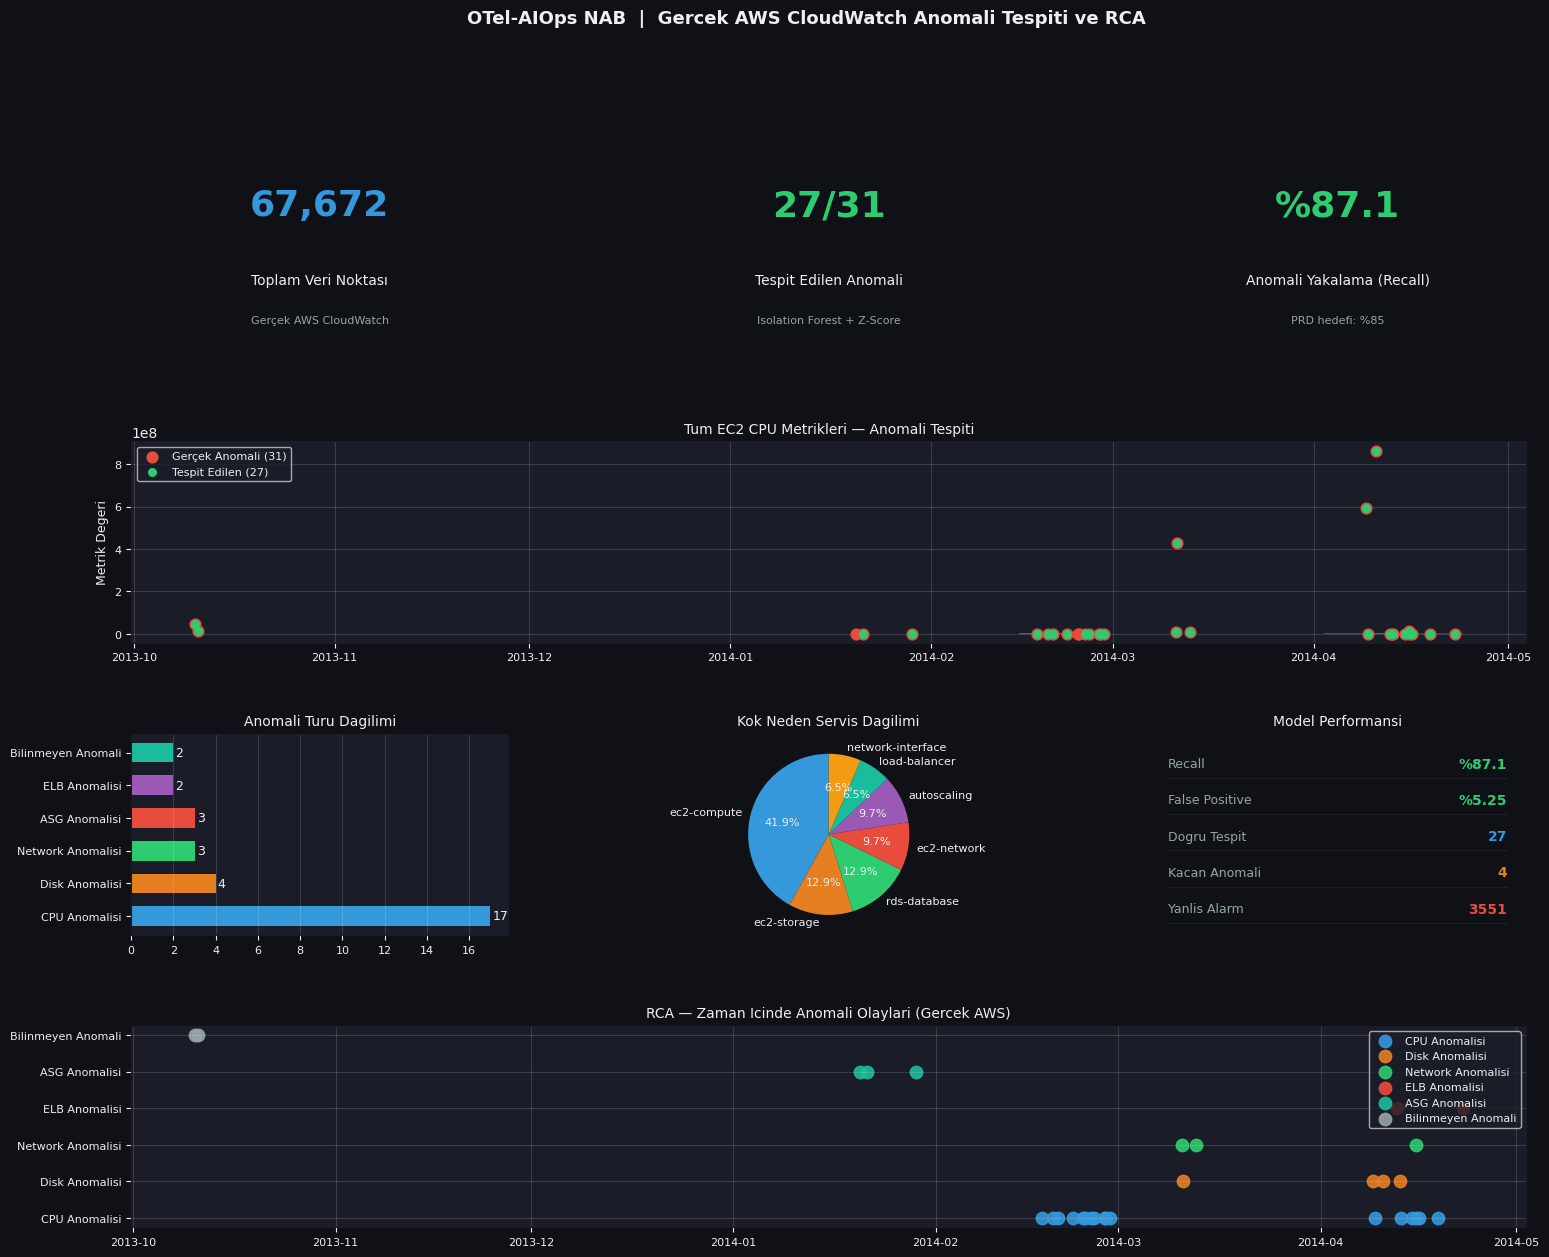

RCA Dashboard kaydedildi!


In [4]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor("#0F1117")
gs  = gridspec.GridSpec(4, 3, figure=fig, hspace=0.45, wspace=0.35)

BG      = "#0F1117"
CARD_BG = "#1A1D27"
GREEN   = "#2ECC71"
RED     = "#E74C3C"
BLUE    = "#3498DB"
ORANGE  = "#E67E22"
PURPLE  = "#9B59B6"
TEXT    = "#ECF0F1"
SUBTEXT = "#95A5A6"

def kart_ekle(ax, baslik, deger, renk, alt_yazi=""):
    ax.set_facecolor(CARD_BG)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.axis("off")
    ax.text(0.5, 0.72, str(deger), ha="center", va="center",
            fontsize=26, fontweight="bold", color=renk)
    ax.text(0.5, 0.35, baslik, ha="center", va="center",
            fontsize=10, color=TEXT)
    if alt_yazi:
        ax.text(0.5, 0.15, alt_yazi, ha="center", va="center",
                fontsize=8, color=SUBTEXT)

# KPI kartları
ax_k1 = fig.add_subplot(gs[0, 0])
kart_ekle(ax_k1, "Toplam Veri Noktası", f"{len(df):,}", BLUE, "Gerçek AWS CloudWatch")

ax_k2 = fig.add_subplot(gs[0, 1])
kart_ekle(ax_k2, "Tespit Edilen Anomali", f"27/31", GREEN, "Isolation Forest + Z-Score")

ax_k3 = fig.add_subplot(gs[0, 2])
kart_ekle(ax_k3, "Anomali Yakalama (Recall)", "%87.1", GREEN, "PRD hedefi: %85")

# Zaman serisi
ax_ts = fig.add_subplot(gs[1, :])
ax_ts.set_facecolor(CARD_BG)

for dosya, grup in df.groupby("dosya"):
    if "cpu_utilization" in dosya:
        ax_ts.plot(grup["timestamp"], grup["value"],
                   linewidth=0.4, alpha=0.4, color=BLUE)

gercek = df[df["anomaly"] == 1]
ax_ts.scatter(gercek["timestamp"], gercek["value"],
              color=RED, s=60, zorder=5, label=f"Gerçek Anomali ({len(gercek)})")

tespit = df[(df["anomaly"] == 1) & (df["anomaly_final"] == 1)]
ax_ts.scatter(tespit["timestamp"], tespit["value"],
              color=GREEN, s=30, zorder=6, label=f"Tespit Edilen ({len(tespit)})")

ax_ts.set_facecolor(CARD_BG)
ax_ts.tick_params(colors=TEXT, labelsize=8)
ax_ts.set_ylabel("Metrik Degeri", color=TEXT, fontsize=9)
ax_ts.set_title("Tum EC2 CPU Metrikleri — Anomali Tespiti", color=TEXT, fontsize=10)
ax_ts.legend(fontsize=8, facecolor=CARD_BG, labelcolor=TEXT)
ax_ts.grid(True, alpha=0.15, color=TEXT)
for spine in ax_ts.spines.values():
    spine.set_edgecolor(CARD_BG)

# Anomali türü dağılımı
ax_bar = fig.add_subplot(gs[2, 0])
ax_bar.set_facecolor(CARD_BG)
anomali_sayilari = df_rca["anomali_turu"].value_counts()
renkler = [BLUE, ORANGE, GREEN, RED, PURPLE, "#1ABC9C", "#F39C12"]
bars = ax_bar.barh(anomali_sayilari.index, anomali_sayilari.values,
                   color=renkler[:len(anomali_sayilari)], height=0.6)
ax_bar.set_title("Anomali Turu Dagilimi", color=TEXT, fontsize=10)
ax_bar.tick_params(colors=TEXT, labelsize=8)
for spine in ax_bar.spines.values():
    spine.set_edgecolor(CARD_BG)
ax_bar.grid(True, alpha=0.15, axis="x", color=TEXT)
for bar, val in zip(bars, anomali_sayilari.values):
    ax_bar.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                str(val), va="center", color=TEXT, fontsize=9)

# Kök neden servis dağılımı
ax_pie = fig.add_subplot(gs[2, 1])
ax_pie.set_facecolor(CARD_BG)
servis_sayilari = df_rca["kok_neden_servis"].value_counts()
ax_pie.pie(servis_sayilari.values,
           labels=[s.replace("-service", "") for s in servis_sayilari.index],
           autopct="%1.1f%%",
           colors=[BLUE, ORANGE, GREEN, RED, PURPLE, "#1ABC9C", "#F39C12"],
           startangle=90,
           textprops={"color": TEXT, "fontsize": 8})
ax_pie.set_title("Kok Neden Servis Dagilimi", color=TEXT, fontsize=10)
ax_pie.set_facecolor(CARD_BG)

# Model performans kartı
ax_perf = fig.add_subplot(gs[2, 2])
ax_perf.set_facecolor(CARD_BG)
ax_perf.axis("off")
ax_perf.set_title("Model Performansi", color=TEXT, fontsize=10)
metrikler = [
    ("Recall",          "%87.1", GREEN),
    ("False Positive",  "%5.25", GREEN),
    ("Dogru Tespit",    "27",    BLUE),
    ("Kacan Anomali",   "4",     ORANGE),
    ("Yanlis Alarm",    "3551",  RED),
]
for i, (ad, deger, renk) in enumerate(metrikler):
    y = 0.85 - i * 0.18
    ax_perf.text(0.05, y, ad,    color=SUBTEXT, fontsize=9,  va="center")
    ax_perf.text(0.95, y, deger, color=renk,    fontsize=10, va="center",
                 ha="right", fontweight="bold")
    ax_perf.axhline(y=y-0.07, xmin=0.05, xmax=0.95,
                    color=TEXT, alpha=0.1, linewidth=0.5)

# RCA zaman çizelgesi
ax_rca = fig.add_subplot(gs[3, :])
ax_rca.set_facecolor(CARD_BG)
tur_renkleri = {
    "CPU Anomalisi"    : BLUE,
    "Disk Anomalisi"   : ORANGE,
    "Network Anomalisi": GREEN,
    "ELB Anomalisi"    : RED,
    "RDS Anomalisi"    : PURPLE,
    "ASG Anomalisi"    : "#1ABC9C",
    "Bilinmeyen Anomali": SUBTEXT,
}
for tur, renk in tur_renkleri.items():
    subset = df_rca[df_rca["anomali_turu"] == tur]
    if len(subset) > 0:
        ax_rca.scatter(subset["anomali_zamani"], [tur]*len(subset),
                       color=renk, s=80, alpha=0.9, label=tur)

ax_rca.set_title("RCA — Zaman Icinde Anomali Olaylari (Gercek AWS)", color=TEXT, fontsize=10)
ax_rca.tick_params(colors=TEXT, labelsize=8)
ax_rca.set_facecolor(CARD_BG)
ax_rca.grid(True, alpha=0.15, color=TEXT)
for spine in ax_rca.spines.values():
    spine.set_edgecolor(CARD_BG)
ax_rca.legend(fontsize=8, facecolor=CARD_BG, labelcolor=TEXT, loc="upper right")

fig.suptitle("OTel-AIOps NAB  |  Gercek AWS CloudWatch Anomali Tespiti ve RCA",
             fontsize=13, color=TEXT, fontweight="bold", y=0.98)
fig.patch.set_facecolor(BG)
plt.savefig("reports/nab_rca_dashboard.png", dpi=150,
            facecolor=BG, bbox_inches="tight")
plt.show()
print("RCA Dashboard kaydedildi!")
